# ⏫ Extracción de datos

## Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importar datos tratados

El conjunto de datos a importar está tratado previamente de acuerdo con el análisis realizado en la primera parte del challenge Telecom X.

In [2]:
url = 'https://raw.githubusercontent.com/gersalfate/challenge-telecom-x-parte-2/refs/heads/main/datos_tratados.csv'

datos = pd.read_csv(url)

## Visualización inicial de los datos

In [3]:
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# 🛠️ Preparación de datos

## Remover variables irrelevantes

La variable 'CustomerID' es única para cada registro y no genera ningún patrón, por lo que solo generaría ruido en el modelo. Se eliminará.

In [5]:
datos = datos.drop(columns=['CustomerID'])

In [6]:
datos.head(1)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3


## Verificación de datos únicos

In [7]:
for columna in datos.columns:

  cantidad_unicos = datos[columna].nunique()
  print(f'{columna}: {cantidad_unicos}')

  if cantidad_unicos < 30:
    valores_unicos = datos[columna].unique()
    print(valores_unicos)
  print('-' * 80)

Churn: 2
['No' 'Yes']
--------------------------------------------------------------------------------
Gender: 2
['Female' 'Male']
--------------------------------------------------------------------------------
SeniorCitizen: 2
['No' 'Yes']
--------------------------------------------------------------------------------
Partner: 2
['Yes' 'No']
--------------------------------------------------------------------------------
Dependents: 2
['Yes' 'No']
--------------------------------------------------------------------------------
Tenure: 73
--------------------------------------------------------------------------------
PhoneService: 2
['Yes' 'No']
--------------------------------------------------------------------------------
MultipleLines: 2
['No' 'Yes']
--------------------------------------------------------------------------------
InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------------------------------------
OnlineSecurity: 2
['No' 

## Verificación de valores nulos

In [8]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# 📊 Análisis de variables

## Correlación entre variables numéricas

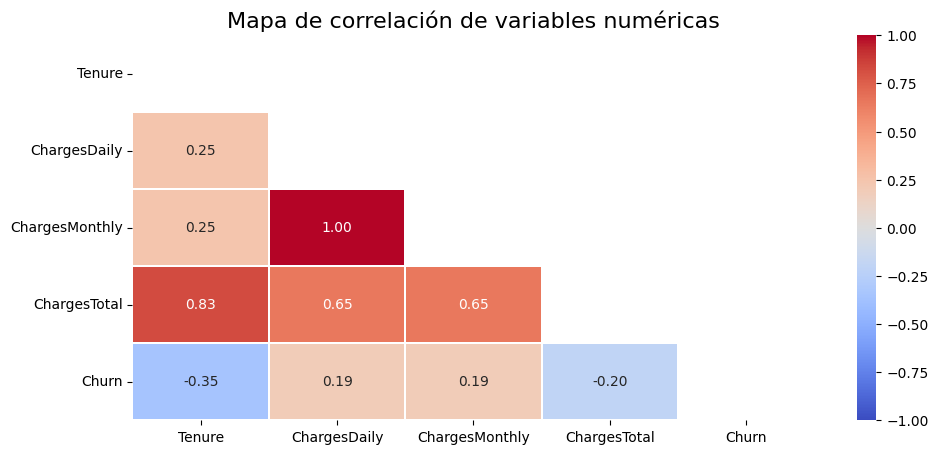

In [9]:
# Selección de variables numéricas
datos_numericos = datos.select_dtypes(include='number')

# Transformación de 'Churn' a variable binaria
datos_numericos['Churn'] = datos['Churn'].replace({'Yes': '1', 'No': '0'}).astype(int)

# Matriz de correlación de variables numéricas
matriz_corr = datos_numericos.corr()

# Mapa de correlación de variables numéricas

mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 5))
ax = sns.heatmap(data=matriz_corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.1)

ax.set_title('Mapa de correlación de variables numéricas', fontsize=16)

plt.show()

Se observa que las variables `ChargesMonthly` y `ChargesDaily` tienen representan una redundancia crítica al tener una correlación de 1.00. Presentan multicolinealidad perfecta ya que representan la misma información. Se mantendrá `ChargesMonthly` ya que es una variable del conjunto de datos original, y además guarda la relación temporal mensual con `Tenure`.

In [10]:
datos = datos.drop(columns='ChargesDaily')

Por otra parte, las variables `ChargesTotal` y `Tenure` tienen una correlación fuerte (0.83). Esto sugiere que posiblemente presenten multicolineadad, representando información similar respecto a la fuga de clientes.

Para determinar si existe multicolinealidad entre las variables, se calcula el Factor de Inflación de la Varianza (VIF).

* $VIF = 1$: No hay correlación.
* $1 < VIF \leq 5$: Correlación moderada.
* $VIF > 5$: Correlación alta (multicolinealidad).

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [12]:
# Seleccionar solo variables numéricas
variables_numericas = datos[['Tenure', 'ChargesMonthly', 'ChargesTotal']]

# Calcular el VIF para cada una
datos_vif = pd.DataFrame()
datos_vif['Variable'] = variables_numericas.columns
datos_vif['VIF'] = [vif(variables_numericas.values, i) for i in range(len(variables_numericas.columns))]

# Ordenar valores
datos_vif = datos_vif.sort_values(by='VIF', ascending=False)
datos_vif

,Variable,VIF
2,ChargesTotal,8.075070
0,Tenure,6.332328
1,ChargesMonthly,3.355660


Se verifica que las variables `ChargesTotal` y `Tenure` tienen presentan multicolinealidad (VIF > 5). Se eliminará la variable `ChargesTotal`, dado que la información de los cargos totales está captuarada de manera implícita en la multiplicación entre la antigüedad del cliente (`Tenure`) y lo que paga mensualmente (`ChargesMonthly`).

In [13]:
datos = datos.drop(columns='ChargesTotal')

## Relación de 'Churn' con las variables categóricas

Primero se realiza una inspección visual para ver el grado de influencia de cada variable en la fuga de clientes.

In [14]:
# Selección de variables categóricas
datos_categoricos = datos.select_dtypes(include='object')

# Eliminación de 'Churn'
datos_categoricos = datos_categoricos.drop(columns='Churn')

In [15]:
for variable in datos_categoricos:

  print(f"📌 Proporción de Churn por: {variable}")
  tabla = pd.crosstab(datos[variable], datos['Churn'], normalize='index') * 100
  display(tabla.style.background_gradient(cmap='Reds', subset=['Yes'], vmin=0, vmax=100))
  print('\n')

📌 Proporción de Churn por: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338




📌 Proporción de Churn por: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261




📌 Proporción de Churn por: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858




📌 Proporción de Churn por: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092




📌 Proporción de Churn por: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Se evidencia que las variables `Gender` y `PhoneService` muestran diferencias mínimas en las proporciones. Son candidatas a ser eliminadas al ser irrelevantes para el modelo.

En contraparte, las variables `InternetService`, `Contract` y `PaymentMethod` muestran las diferencias más altas en las proporciones, mostrando que son relevantes para el modelo.

Para verificar la significancia estadística de cada variable, se realiza la prueba de independencia Chi-cuadrado ($\chi^2$).

* Hipótesis nula ($H_0$): La variable no tiene relación con `Churn` (p-valor $> 0.05$).
* Hipótesis alternativa ($H_1$): La variable tiene relación con `Churn` (p-valor $\leq 0.05$).

In [16]:
from scipy.stats import chi2_contingency

In [17]:
# Lista para almacenar los resultados
resultados_test = []

for variable in datos_categoricos:
  # Crear la tabla de contingencia (frecuencias absolutas)
  tabla = pd.crosstab(datos[variable], datos['Churn'])

  # Ejecutar el test de Chi-cuadrado
  chi2, p, dof, ex = chi2_contingency(tabla)

  # Guardar si es significativa o no (usando el umbral estándar de 0.05)
  resultados_test.append({'Variable': variable,
                          'p-valor': p,
                          'Significativa': 'Sí' if p <= 0.05 else 'No'})

# Convertir a DataFrame para una visualización limpia
df_chi2 = pd.DataFrame(resultados_test).sort_values(by='p-valor')
df_chi2

,Variable,p-valor,Significativa
13,Contract,5.863038e-258,Sí
6,InternetService,9.571788e-160,Sí
15,PaymentMethod,3.682355e-140,Sí
14,PaperlessBilling,4.073355e-58,Sí
7,OnlineSecurity,1.232098e-46,Sí
10,TechSupport,2.923567e-43,Sí
3,Dependents,4.924922e-43,Sí
1,SeniorCitizen,1.510067e-36,Sí
2,Partner,2.139911e-36,Sí
8,OnlineBackup,6.214093e-12,Sí


Se verifica estadísticamente que las variables `InternetService`, `Contract` y `PaymentMethod` son las más significativas para el modelo, a la vez que las variables `Gender` y `PhoneService` no son significativas. Se eliminarán estas dos últimas al ser irrelevantes para el modelo.


In [18]:
datos = datos.drop(columns=['Gender', 'PhoneService'])

In [19]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  ChargesMonthly    7043 non-null   float64


# 💱 Transformación y separación de datos

## Separación de variables explicativas y objetivo

In [20]:
# Variables explicativas
X = datos.drop(columns='Churn')

# Variable objetivo
y = datos['Churn']

## Transformación de variables explicativas

In [21]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [22]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                  ['SeniorCitizen', 'Partner', 'Dependents','MultipleLines', 'InternetService', 'OnlineSecurity',
                                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                                   'StreamingTV', 'StreamingMovies', 'Contract',
                                   'PaperlessBilling', 'PaymentMethod']),
                                  remainder= 'passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [23]:
X = one_hot.fit_transform(X)

In [24]:
# Convertir a DataFrame
X = pd.DataFrame(X, columns=one_hot.get_feature_names_out())
X.head()

,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,...,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.6
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.9
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.9
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.9


In [25]:
# Eliminar los prefijos para que sea más legible
X.columns = [columna.split('__')[-1] for columna in X.columns]
X.head()

,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure,ChargesMonthly
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.6
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.9
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.9
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.9


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen_Yes                        7043 non-null   float64
 1   Partner_Yes                              7043 non-null   float64
 2   Dependents_Yes                           7043 non-null   float64
 3   MultipleLines_Yes                        7043 non-null   float64
 4   InternetService_DSL                      7043 non-null   float64
 5   InternetService_Fiber optic              7043 non-null   float64
 6   InternetService_No                       7043 non-null   float64
 7   OnlineSecurity_Yes                       7043 non-null   float64
 8   OnlineBackup_Yes                         7043 non-null   float64
 9   DeviceProtection_Yes                     7043 non-null   float64
 10  TechSupport_Yes                          7043 no

## Transformación de variable objetivo

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
label_encoder = LabelEncoder()

In [29]:
y = label_encoder.fit_transform(y)

In [30]:
y

array([0, 0, 1, ..., 0, 0, 0])

## Separación de datos de entrenamiento y prueba

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=55)

# 🎯 Creación de modelos predictivos

## Modelo base (dummy)

In [33]:
from sklearn.dummy import DummyClassifier

In [34]:
modelo_dummy = DummyClassifier()

In [35]:
modelo_dummy.fit(X_train, y_train)

DummyClassifier()

In [36]:
y_pred_dummy = modelo_dummy.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

In [38]:
print('Resultados: Modelo base (dummy)\n')
print(classification_report(y_test, y_pred_dummy, zero_division=0))

Resultados: Modelo base (dummy)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

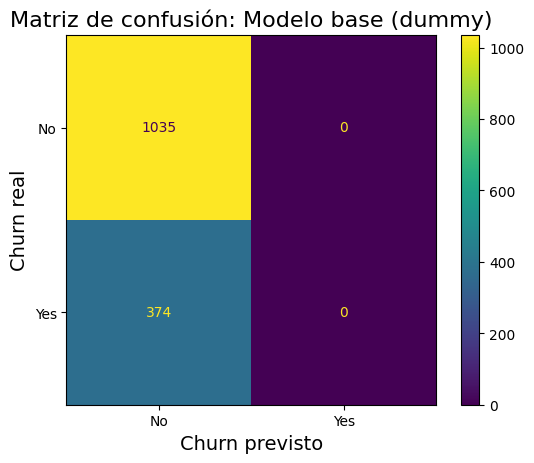

In [40]:
mc_dummy = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dummy))
mc_dummy.plot()

plt.title('Matriz de confusión: Modelo base (dummy)', fontsize=16)
plt.xlabel('Churn previsto', fontsize=14)
plt.ylabel('Churn real', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Este modelo no es capaz de predecir clientes que se fuguen. Sin embargo, sus métricas son de utilidad como referencia de comparación con modelos más complejos.

## Regresión logística

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
modelo_log = LogisticRegression(max_iter=1000, random_state=55)

In [43]:
modelo_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=55)

In [44]:
y_pred_log = modelo_log.predict(X_test)

In [45]:
print('Resultados: Regresión logística\n')
print(classification_report(y_test, y_pred_log))

Resultados: Regresión logística

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



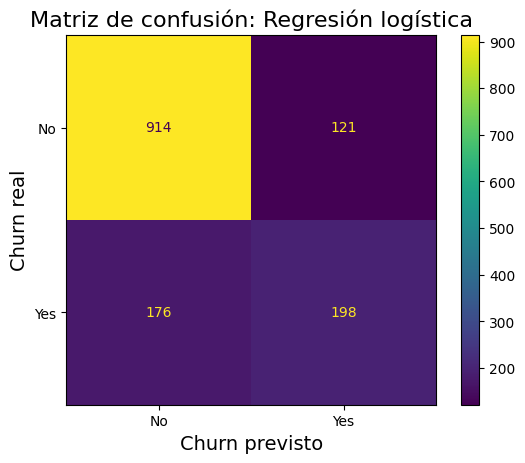

In [46]:
mc_log = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log))
mc_log.plot()

plt.title('Matriz de confusión: Regresión logística', fontsize=16)
plt.xlabel('Churn previsto', fontsize=14)
plt.ylabel('Churn real', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Se evidencian mejoras en todas las métricas respecto al modelo base. Sin embargo, las variables explicativas no están estandarizadas. Se debe mejorar el modelo.

## Regresión logística mejorada

Para asegurar que el modelo converja correctamente y que los coeficientes sean comparables, se aplica una estandarización a las variables numéricas. Además, se ajustan los pesos de las clases para compensar el desbalance en los datos de fuga (de acuerdo al análisis exploratorio de la primera parte del proyecto).

Nueva transformación de variables explicativas con escalado.

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
columnas_numericas = ['Tenure', 'ChargesMonthly']
columnas_categoricas = ['SeniorCitizen', 'Partner', 'Dependents',
                        'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract',
                        'PaperlessBilling', 'PaymentMethod']

procesador_escalado = make_column_transformer((StandardScaler(), columnas_numericas),
                                             (OneHotEncoder(drop='if_binary'), columnas_categoricas), sparse_threshold=0)

X_escalado = procesador_escalado.fit_transform(datos.drop(columns='Churn'))

X_escalado = pd.DataFrame(X_escalado, columns=procesador_escalado.get_feature_names_out())
X_escalado.columns = [columna.split('__')[-1] for columna in X_escalado.columns]

Nueva separación de datos de entrenamiento y prueba.

In [49]:
X_escalado_train, X_escalado_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.2, stratify=y, random_state=55)

Nueva regresión logística.

In [50]:
# Se agrega parámetro que penaliza errores en clase minoritaria para maximizar recall de fuga
modelo_log_mejorado = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=55)

In [51]:
modelo_log_mejorado.fit(X_escalado_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=55)

In [52]:
y_pred_log_mejorado = modelo_log_mejorado.predict(X_escalado_test)

In [53]:
print('Resultados: Regresión logística mejorada\n')
print(classification_report(y_test, y_pred_log_mejorado))

Resultados: Regresión logística mejorada

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



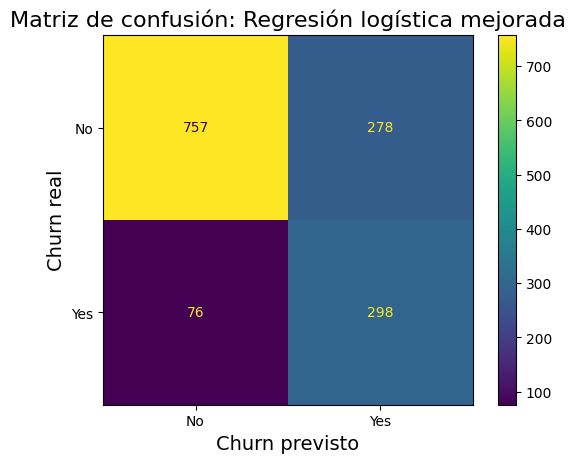

In [54]:
mc_log_mejorado = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log_mejorado))
mc_log_mejorado.plot()

plt.title('Matriz de confusión: Regresión logística mejorada', fontsize=16)
plt.xlabel('Churn previsto', fontsize=14)
plt.ylabel('Churn real', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Al mejorar la regresión logística, se sacrifica la detección de clientes que se mantienen, a cambio de lograr un aumento en la detección de clientes fugados.

## Random forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=55)

In [57]:
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=55)

In [58]:
y_pred_rf = modelo_rf.predict(X_test)

In [59]:
print('Resultados: Random forest\n')
print(classification_report(y_test, y_pred_rf))

Resultados: Random forest

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



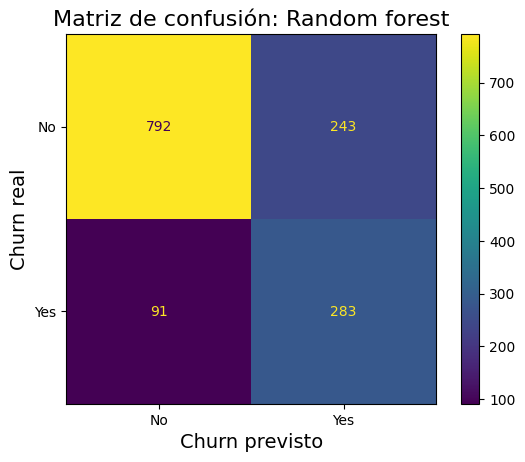

In [60]:
mc_rf = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf))
mc_rf.plot()

plt.title('Matriz de confusión: Random forest', fontsize=16)
plt.xlabel('Churn previsto', fontsize=14)
plt.ylabel('Churn real', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Los resultados son similares al modelo anterior. Es capaz de detectar una cantidad similar de clientes fugados.

# 📝 Evaluación de los modelos

## Overfitting o Underfitting

Regresión logística mejorada.

In [61]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [62]:
# Predicciones con los datos de entrenamiento
y_train_pred_log = modelo_log_mejorado.predict(X_escalado_train)

# Predicciones con los datos de prueba
y_test_pred_log = modelo_log_mejorado.predict(X_escalado_test)

# Métricas

acc_train_log = accuracy_score(y_train, y_train_pred_log)
acc_test_log = accuracy_score(y_test, y_test_pred_log)

f1_train_log = f1_score(y_train, y_train_pred_log)
f1_test_log = f1_score(y_test, y_test_pred_log)

print('Regresión logística mejorada\n')
print(f"Accuracy: Entrenamiento: {acc_train_log:.2f} | Prueba: {acc_test_log:.2f} | Diferencia: {acc_test_log - acc_train_log:.2f}")
print(f"F1-score: Entrenamiento: {f1_train_log:.2f} | Prueba: {f1_test_log:.2f} | Diferencia: {f1_test_log - f1_train_log:.2f}")

Regresión logística mejorada

Accuracy: Entrenamiento: 0.75 | Prueba: 0.75 | Diferencia: -0.00
F1-score: Entrenamiento: 0.63 | Prueba: 0.63 | Diferencia: -0.00


Dado que la diferencia en ambos indicadores es nula, se verifica que la regresión logística mejorada es un modelo que se ajusta de manera adecuada a los datos y es confiable al evaluar datos nuevos.

Random forest.

In [63]:
# Predicciones con los datos de entrenamiento
y_train_pred_rf = modelo_rf.predict(X_train)

# Predicciones con los datos de prueba
y_test_pred_rf = modelo_rf.predict(X_test)

# Métricas

acc_train_rf = accuracy_score(y_train, y_train_pred_rf)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)

f1_train_rf = f1_score(y_train, y_train_pred_rf)
f1_test_rf = f1_score(y_test, y_test_pred_rf)

print('Random forest\n')
print(f"Accuracy: Entrenamiento: {acc_train_rf:.2f} | Prueba: {acc_test_rf:.2f} | Diferencia: {acc_test_rf - acc_train_rf:.2f}")
print(f"F1-score: Entrenamiento: {f1_train_rf:.2f} | Prueba: {f1_test_rf:.2f} | Diferencia: {f1_test_rf - f1_train_rf:.2f}")

Random forest

Accuracy: Entrenamiento: 0.85 | Prueba: 0.76 | Diferencia: -0.09
F1-score: Entrenamiento: 0.76 | Prueba: 0.63 | Diferencia: -0.13


Ambos indicadores disminuyeron al usar los datos de prueba, revelando que el modelo de bosque aleatorio se sobreajustó a los de entrenamiento (overfitting). Se ajustará la profundidad para mejorarlo.

## Random forest mejorado

In [64]:
modelo_rf_mejorado = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=55)

In [65]:
modelo_rf_mejorado.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=7, random_state=55)

In [66]:
y_pred_rf_mejorado = modelo_rf_mejorado.predict(X_test)

In [67]:
print('Resultados: Random forest mejorado\n')
print(classification_report(y_test, y_pred_rf_mejorado))

Resultados: Random forest mejorado

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409



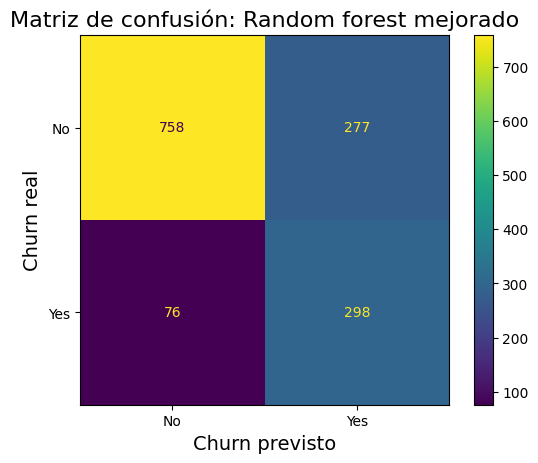

In [68]:
mc_rf_mejorado = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf_mejorado))
mc_rf_mejorado.plot()

plt.title('Matriz de confusión: Random forest mejorado', fontsize=16)
plt.xlabel('Churn previsto', fontsize=14)
plt.ylabel('Churn real', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Se evaluará el overfitting de este modelo mejorado.

In [69]:
# Predicciones con los datos de entrenamiento
y_train_pred_rf_mejorado = modelo_rf_mejorado.predict(X_train)

# Predicciones con los datos de prueba
y_test_pred_rf_mejorado = modelo_rf_mejorado.predict(X_test)

# Métricas

acc_train_rf_mejorado = accuracy_score(y_train, y_train_pred_rf_mejorado)
acc_test_rf_mejorado = accuracy_score(y_test, y_test_pred_rf_mejorado)

f1_train_rf_mejorado = f1_score(y_train, y_train_pred_rf_mejorado)
f1_test_rf_mejorado = f1_score(y_test, y_test_pred_rf_mejorado)

print('Random forest mejorado\n')
print(f"Accuracy: Entrenamiento: {acc_train_rf_mejorado:.2f} | Prueba: {acc_test_rf_mejorado:.2f} | Diferencia: {acc_test_rf_mejorado - acc_train_rf_mejorado:.2f}")
print(f"F1-score: Entrenamiento: {f1_train_rf_mejorado:.2f} | Prueba: {f1_test_rf_mejorado:.2f} | Diferencia: {f1_test_rf_mejorado - f1_train_rf_mejorado:.2f}")

Random forest mejorado

Accuracy: Entrenamiento: 0.77 | Prueba: 0.75 | Diferencia: -0.02
F1-score: Entrenamiento: 0.66 | Prueba: 0.63 | Diferencia: -0.03


Dado que la diferencia en ambos indicadores es prácticamente nula, se verifica que el bosque aleatorio mejorado es un modelo que se ajusta de manera adecuada a los datos y es confiable al evaluar datos nuevos, al igual que la regresión logística mejorada.

## Análisis de importancia de las variables

Regresión logística mejorada.

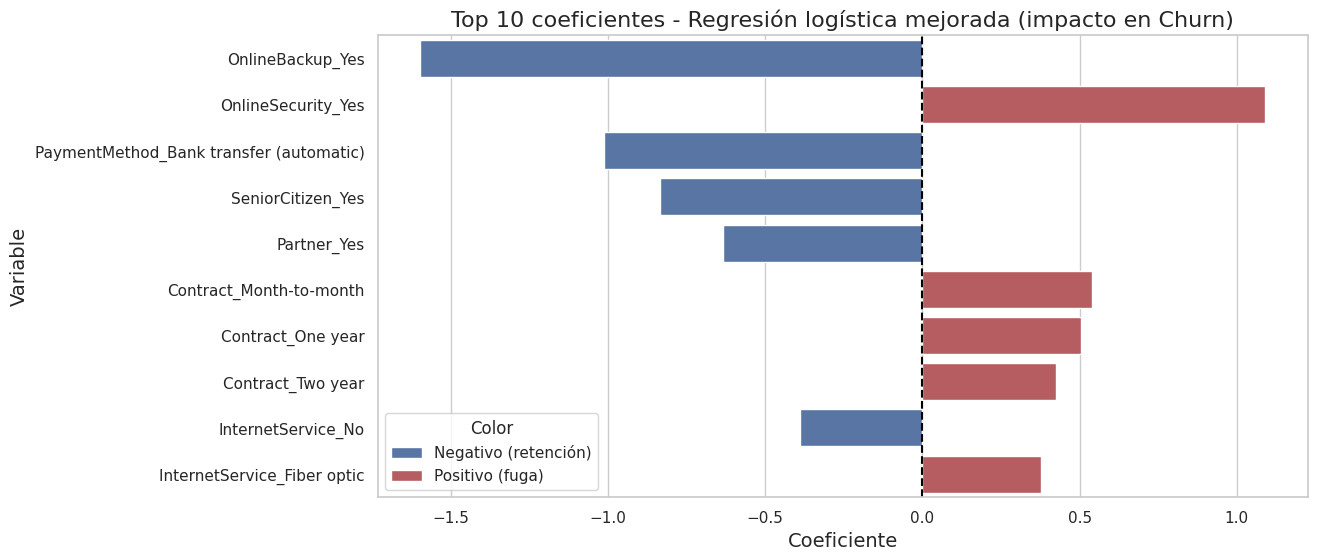

In [70]:
# Definir estilo
sns.set_theme(style='whitegrid')

# Extraer coeficientes
coeficientes = modelo_log_mejorado.coef_[0]
nombres_variables = X_train.columns

# Crear un DataFrame para facilitar la visualización
df_importancia_log = pd.DataFrame({'Variable': nombres_variables,
                                   'Coeficiente': coeficientes})
df_importancia_log['Color'] = ['Positivo (fuga)' if x > 0 else 'Negativo (retención)' for x in df_importancia_log['Coeficiente']]

# Ordenar por valor absoluto para ver las más influyentes primero
df_importancia_log['|Coeficiente|'] = df_importancia_log['Coeficiente'].abs()
df_importancia_log = df_importancia_log.sort_values(by='|Coeficiente|', ascending=False)

# Graficar las 10 principales
plt.figure(figsize=(12, 6))
sns.barplot(x='Coeficiente', y='Variable', hue='Color', data=df_importancia_log.head(10),
            palette={'Positivo (fuga)': '#C44E52', 'Negativo (retención)': '#4C72B0'})
plt.title('Top 10 coeficientes - Regresión logística mejorada (impacto en Churn)', fontsize=16)
plt.xlabel('Coeficiente', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

Random forest mejorado.

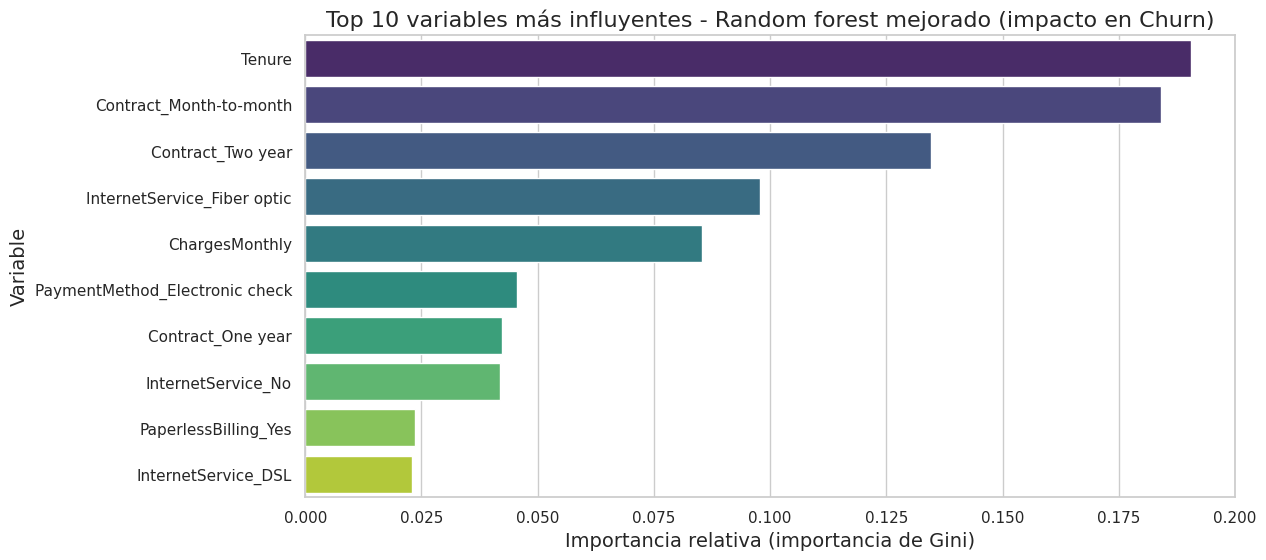

In [71]:
# Extraer importancias del Random Forest mejorado
importancias_rf = pd.DataFrame({'Variable': X_train.columns,
                                'Importancia': modelo_rf_mejorado.feature_importances_
                                }).sort_values(by='Importancia', ascending=False)

# Graficar las 10 principales
plt.figure(figsize=(12, 6))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=importancias_rf.head(10),
            palette='viridis', legend=False)
plt.title('Top 10 variables más influyentes - Random forest mejorado (impacto en Churn)', fontsize=16)
plt.xlabel('Importancia relativa (importancia de Gini)', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.show()

## Elección del modelo de mejor desempeño

Tanto la regresión logística mejorada como el random forest mejorado tienen las mismas métricas de rendimiento, siendo modelos que tienen bases matemáticas muy diferentes para llegar a la predicción de la variable objetivo. Esto sugiere que probablemente se haya alcanzado un techo de rendimiento con la información disponible.

Para este contexto y considerando la naturaleza de cada modelo, se elige la regresión logística mejorada:

* Empate de métricas: Dado que ambos modelos tienen el mismo rendimiento en todas las métricas relevantes, es preferible la regresión logística al ser un modelo más simple, que es más fácil de mantener y que consume menos recursos.

* Diferencia en datos de entrenamiento y prueba: La regresión logística tiene nula variación al evaluar los datos de prueba, siendo más estable en términos generalización con respecto al random forest.

* Interpretabilidad: Cada variable tiene un coeficiente asociado, por lo que no solo se puede cuantificar el grado de importancia a cada uno, sino que también en qué dirección influye (retención o fuga de clientes).

## Validación del modelo con nuevos datos

Se entregarán dos datos con perfiles opuestos para ver si el modelo sigue con la lógica:

* Perfil A: Cliente fidelizado.
* Perfil B: Cliente en riesgo de fuga.

In [72]:
# Definir perfiles simulados

perfil_A = {
    'Tenure': 65, # Alta antigüedad
    'ChargesMonthly': 24.50, # Cargo bajo
    'SeniorCitizen': 'Yes', # Adulto mayor
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'DSL', # Tecnología de menor riesgo
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes', # Factor clave de retención
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Two year', # Contrato de largo plazo
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Bank transfer (automatic)'
    }

perfil_B = {
    'Tenure': 2, # Cliente nuevo
    'ChargesMonthly': 98.85, # Cargo mensual elevado
    'SeniorCitizen': 'No',
    'Partner': 'No',
    'Dependents': 'No',
    'MultipleLines': 'Yes',
    'InternetService': 'Fiber optic', # Tecnología de mayor riesgo
    'OnlineSecurity': 'Yes', # Factor clave de riesgo de fuga
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month', # Contrato con riesgo de fuga
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check'
    }

In [73]:
# Transformar diccionarios en DataFrame
datos_simulados = pd.DataFrame([perfil_A, perfil_B], index=['Perfil A (fidelizado)', 'Perfil B (riesgo)'])
datos_simulados

,Tenure,ChargesMonthly,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Perfil A (fidelizado),65,24.50,Yes,Yes,Yes,No,DSL,No,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic)
Perfil B (riesgo),2,98.85,No,No,No,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check


In [74]:
# Aplicar transformación de datos
X_simulados = procesador_escalado.transform(datos_simulados)
X_simulados = pd.DataFrame(X_simulados, columns=procesador_escalado.get_feature_names_out())
X_simulados.columns = [columna.split('__')[-1] for columna in X_simulados.columns]

In [75]:
# Predicciones del modelo
y_simulados = modelo_log_mejorado.predict(X_simulados)

# Probabilidad de fuga de los perfiles según el modelo
y_prob = modelo_log_mejorado.predict_proba(X_simulados)[:, 1]

# Unificar resultados en un DataFrame para el reporte
analisis_final = pd.DataFrame({
    'Predicción (0=No, 1=Sí)': y_simulados,
    'Probabilidad de fuga (%)': (y_prob * 100).round(2)
}, index=['Perfil A (fidelizado)', 'Perfil B (riesgo)'])

analisis_final

,"Predicción (0=No, 1=Sí)",Probabilidad de fuga (%)
Perfil A (fidelizado),0,4.49
Perfil B (riesgo),1,92.02


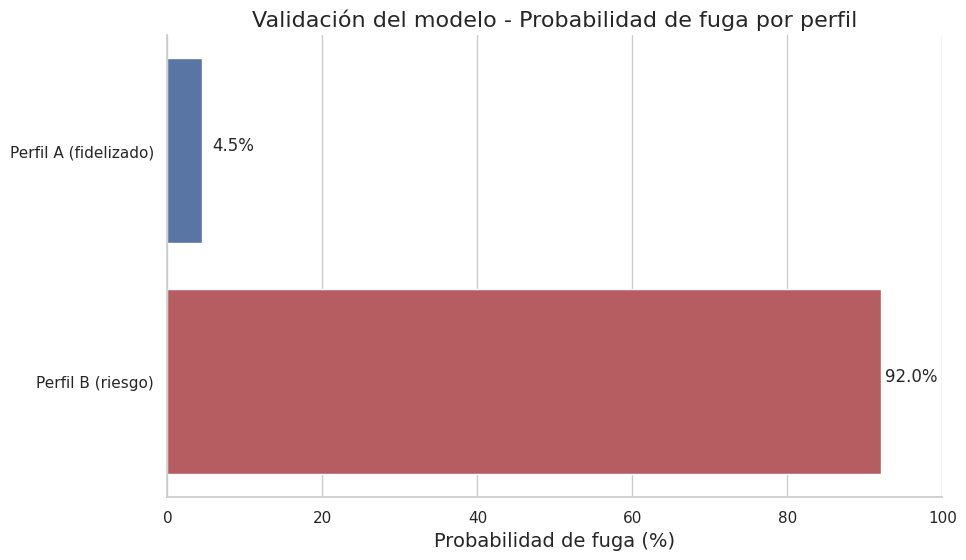

In [76]:
# Graficar las probabilidades

plt.figure(figsize=(10, 6))
sns.barplot(data=analisis_final, x='Probabilidad de fuga (%)', y=analisis_final.index,
            hue=analisis_final.index, palette=['#4C72B0', '#C44E52'], legend=False)

plt.title('Validación del modelo - Probabilidad de fuga por perfil', fontsize=16)
plt.xlabel('Probabilidad de fuga (%)', fontsize=14)
plt.ylabel('')
plt.xlim(0, 100)

for i, porcentaje in enumerate(analisis_final['Probabilidad de fuga (%)']):
  plt.text(porcentaje+4, i, f'{porcentaje:.1f}%', ha='center')

sns.despine()
plt.show()

El modelo se desempeña de manera óptima ante estos datos simulados con perfiles definidos, prediciendo la probabilidad de fuga de cada uno de acuerdo con lo esperada para cada perfil.

# 📄 Informe final

## Introducción

El propósito del presente estudio es continuar con el análisis de datos de la empresa Telecom X en el contexto del proyecto "Churn de Clientes", siendo esta la segunda parte. La empresa enfrenta una alta tasa de cancelaciones y necesita identificar los factores críticos que llevan a la pérdida de clientes.

La nueva misión de la empresa es anticiparse al problema de cancelación, para lo cual busca desarrollar modelos predictivos de aprendizaje automático capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

Los objetivos de este desafío son:

* Preparar los datos para el modelado (tratamiento, codificación, normalización).

* Realizar análisis de correlación y selección de variables.

* Entrenar dos o más modelos de clasificación.

* Evaluar el rendimiento de los modelos con métricas.

* Interpretar los resultados, incluyendo la importancia de las variables.

* Dar a conocer los hallazgos clave y realizar recomendaciones estratégicas.

## Preparación de datos

El proceso de preparación de datos para el modelado se divide en las siguientes etapas:

* Importación:
  - Importación de las librerías a utilizar.
  - Importación de los datos tratados de la primera parte mediante la biblioteca Pandas.
  - Visualización general de los datos.

* Limpieza:
  - Remoción de variable de identificación (`customerID`) que no aporta valor predictivo a los modelos.
  - Verificación de consistencia de datos únicos.
  - Verificación de ausencia de valores nulos.

## Análisis de variables

### Correlación entre variables numéricas

Es probable que no todas las variables numéricas aporten valor a los modelos predictivos. Se realiza un mapa de correlación para ver qué variables son candidatas a ser eliminadas.

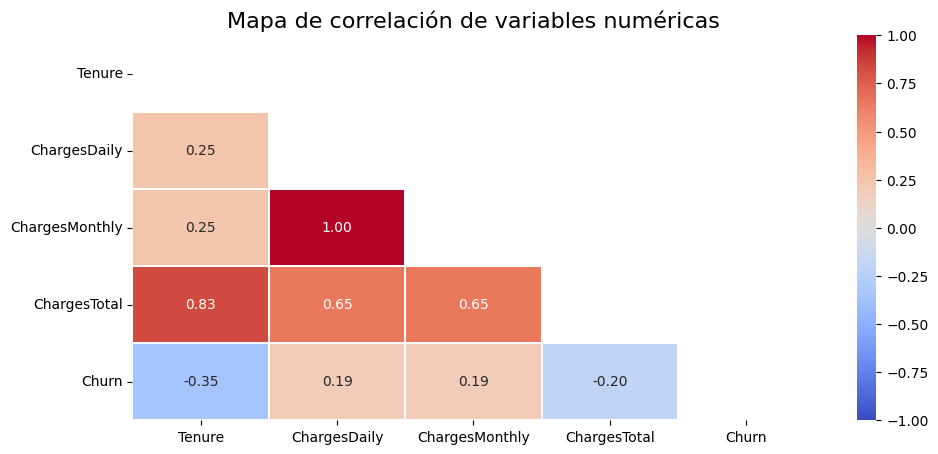

Las variables `ChargesMonthly` y `ChargesDaily` tienen una correlación perfecta (1.00), es decir, representan la misma variable. Se mantiene `ChargesMonthly` por ser la variable del dataset original y tener relación de temporalidad mensual con la variable `Tenure`.

Asimismo, las variables `ChargesTotal` y `Tenure` tienen una correlación fuerte (0.83), lo que sugiere una posible multicolineadad, representando información similar respecto a la fuga de clientes.

Para determinar si hay que eliminar alguna, se calcula el Factor de Inflación de la Varianza (VIF) entre las tres variables numéricas, lo que confirma la multicolinealidad entre `ChargesTotal` y `Tenure`. Se decide eliminar `ChargesTotal` dado que es una variable derivada que se puede obtener mediante la multiplicación entre `ChargesMonthly` y `Tenure`, ayudando a reducir la redundancia y simplicando los modelos sin perder información.

### Relación de 'Churn' con las variables categóricas

Inicialmente se visualiza qué tan influyente es cada variable en la fuga de clientes. Por una parte, `Gender` y `PhoneService` son candidatas a ser eliminadas al mostrar diferencias mínimas en las proporciones en relación a la fuga. En tanto, `InternetService`, `Contract` y `PaymentMethod` muestran que son candidatas a ser relevantes para los modelos.

Para determinar cuáles variables categóricas se deben eliminar de acuerdo con su significancia estadística, se realiza la prueba de independencia Chi-cuadrado ($\chi^2$). La prueba revela que el p-valor para `Gender` y `PhoneService` es mayor que 0.05, lo que indica que no hay evidencia estadística suficiente para rechazar la independencia respecto a la fuga de clientes, confirmando la inspección visual previa, por lo que se eliminan del dataset.

## Transformación y separación de datos

El proceso de transformación y separación de datos para el modelado se divide en los siguientes pasos:

* Separación de variables explicativas (features) y objetivo (target).
* Transformación de variables explicativas categóricas con `OneHotEncoder`.
* Transformación de variable objetivo con `LabelEncoder`.
* Separación de datos en conjuntos de entrenamiento y prueba (`train_test_split`).

## Creación y evaluación de modelos predictivos

Se realizarán y evaluarán tres modelos de predicción:

* Modelo base (dummy).
* Regresión logística.
* Random forest.

### Modelo base (dummy)

Si bien no se debe esperar que este modelo presente un buen rendimiento, es utilizado como modelo de referencia y para tener conocimiento de sus métricas en relación con su capacidad de predicción, que deberían ser superadas por los modelos más complejos.

Los principales resultados del modelo dummy son:

* Accuracy = 0.73
* Precision (fuga) = 0.00
* Recall (fuga) = 0.00
* F1-score (fuga) = 0.00

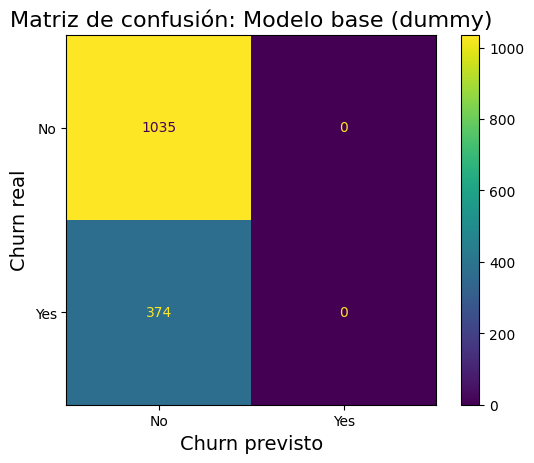

Se observa que a pesar de tener una exactitud (accuracy) del 73%, es engañoso porque el modelo no es capaz de predecir fugas, que es el objetivo principal de este análisis. Esto se verifica en las métricas nulas de la precisión, recuperación (recall) y F1-score en relación a la fuga. Es necesario crear más modelos para mejorar la predicción clientes fugados.

La exactitud del 73% refleja la proporción de la clase mayoritaria en el dataset (clientes que se mantienen). Esto demuestra que la exactitud no es una métrica adecuada para este problema de clases desbalanceadas, justificando el uso del precision, recall y sobre todo F1-score en los modelos siguientes.

### Regresión logística

En primera instancia, se realiza una regresión logística sin considerar la estandarización de los datos dadas las distintas escalas entre las variables numéricas. Se decide de esta forma para ver rápidamente si este modelo es capaz de superar al modelo dummy.

Los principales resultados de la regresión logística son:

* Accuracy = 0.79
* Precision (fuga) = 0.62
* Recall (fuga) = 0.53
* F1-score (fuga) = 0.57

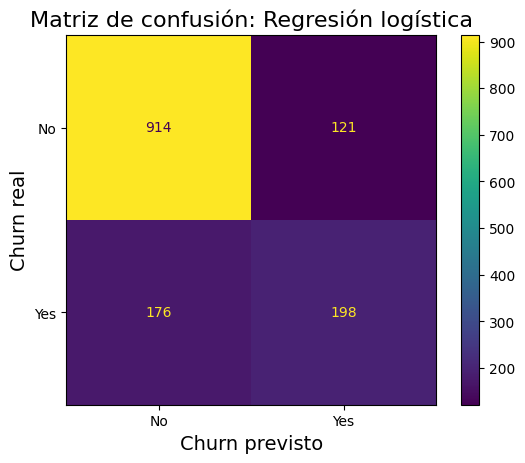

Se aprecia una mejora de 6% en la exactitud. Sin embargo, el valor real de este modelo es la mejora significativa en las otras métricas, pues este modelo es capaz de detectar fugas de clientes con un 62% de precisión, con un 53% de sensibilidad (recall), y presentando un F1-score de 57%. Es decir, es capaz de predecir correctamente más de la mitad de las fugas reales de clientes.

No obstante, la regresión logística es un modelo que requiere que las variables numéricas sean estandarizadas en una misma escala. Además, este conjunto de datos está desbalanceado (de acuerdo al análisis exploratorio de la primera parte del proyecto).

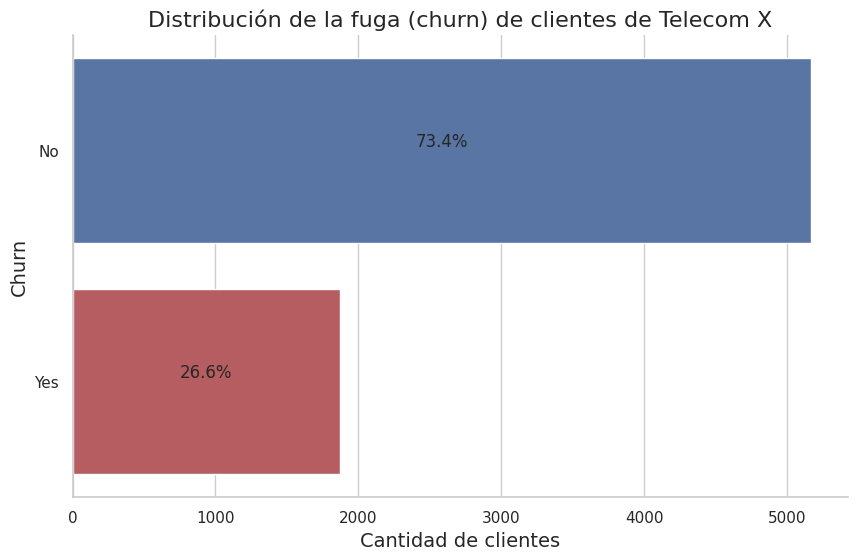

Dado este contexto, se decide ajustar los pesos de las clases para compensar el desbalance en los datos de fuga, en conjunto con el escalado de datos.

El proceso para estandarización de datos implica una nueva transformación y separación de datos, que incluye los siguientes pasos:

* Nueva transformación de variables explicativas numéricas con `StandardScaler` y categóricas con `OneHotEncoder`.
* Nueva separación de datos en conjuntos de entrenamiento y prueba `(train_test_split`).

Los principales resultados de la regresión logística mejorada son:

* Accuracy = 0.75
* Precision (fuga) = 0.52
* Recall (fuga) = 0.80
* F1-score (fuga) = 0.63

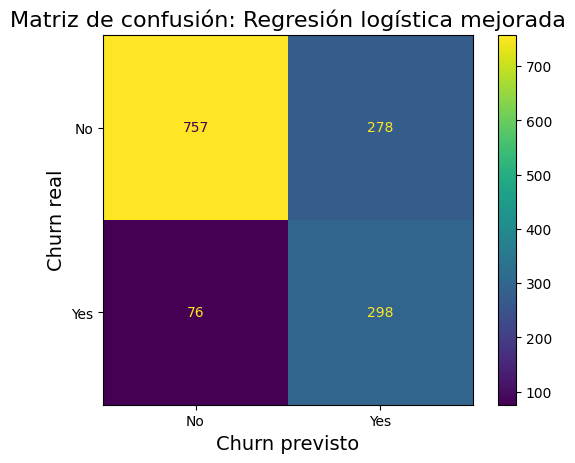

Si bien la exactitud disminuye un 4% y la precisión de la fuga 10% con respecto a la regresión logística inicial, la sensibilidad (recall) aumenta un 27% y el F1-score un 6%.

Esta configuración es preferible para la empresa. A pesar de que este modelo mejorado detecta más falsos positivos (clientes que según el modelo se fugan y que en realidad se quedan), logra capturar el 80% de las fugas reales (verdaderos positivos) y disminuir los falsos negativos (clientes que según el modelo se quedan y en realidad se fugan). Es estratégicamente más rentable ofrecer incentivos de retención a clientes que de todas maneras se quedarían en la empresa, a sufrir la fuga inesperada de clientes por no haber detectado el riesgo de fuga a tiempo. El aumento del F1-score confirma que este equilibrio entre la precisión y la sensibilidad hace que este modelo sea más robusto y esté mejor balanceado frente a la regresión logística inicial.

### Random forest

Para contrastar el modelo anterior con uno más complejo, se implementa la creación de un modelo predictivo de bosque aleatorio. Este modelo no requiere la estandarización de las variables, por lo que se usan los datos con la transformación inicial.

Los principales resultados del random forest son:

* Accuracy = 0.76
* Precision (fuga) = 0.54
* Recall (fuga) = 0.76
* F1-score (fuga) = 0.63

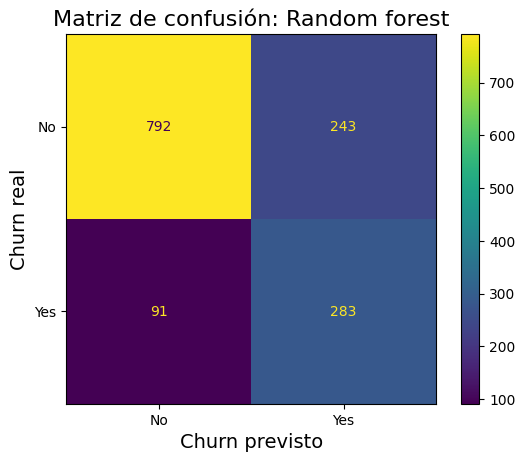

Las métricas de rendimiento son muy similares con respecto a la regresión logística mejorada. El modelo predice correctamente un 76% de las fugas (sensibilidad) y el F1-score se mantiene en un 63%.

No obstante, es siempre necesario evaluar el sobreajuste (overfitting) o subajuste (underfitting) de los modelos, con el fin de favorecer que identifiquen los patrones de los datos y evitar que se los aprendan de memoria y sean incapaces de predecir fugas con nuevos datos.

Al evaluar el ajuste de los datos en los modelos entre los datos de entrenamiento y prueba, se obtiene:

* Regresión logística mejorada:
  - Accuracy: Entrenamiento: 0.75 | Prueba: 0.75 | Diferencia: 0.00
  - F1-score: Entrenamiento: 0.63 | Prueba: 0.63 | Diferencia: 0.00

* Random forest:
  - Accuracy: Entrenamiento: 0.85 | Prueba: 0.76 | Diferencia: -0.09
  - F1-score: Entrenamiento: 0.76 | Prueba: 0.63 | Diferencia: -0.13

La regresión logística mejorada tiene un rendimiento idéntico entre los datos de entrenamiento y prueba. Comprendió perfectamente los patrones en los datos demostrando una alta capacidad de generalización a nuevos datos.

En tanto, el random forest presenta métricas altas para datos de entrenamiento, pero tiene una disminución del 9% en la exactitud al evaluar nuevos datos y una baja del 13% en el F1-score, que es contundente al señalar que tiene un rendimiento menor en la detección de fugas de clientes nuevos, ya que está sobreajustada a los datos de entrenamiento (overfitting). Para corregir esto, se decide ajustar el hiperparámetro de profundidad del bosque (`max_depth`) de 10 a 7, una medida efectiva para simplificar el modelo y forzarlo a capturar solo los patrones más relevantes e ignorar el ruido.

Los principales resultados del random forest mejorado son:

* Accuracy = 0.75
* Precision (fuga) = 0.52
* Recall (fuga) = 0.80
* F1-score (fuga) = 0.63

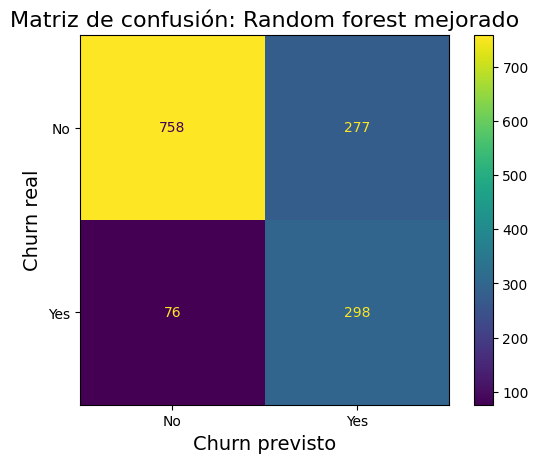

Respecto al random forest inicial, la exactitud bajó un 1%, la precisión un 2% y el F1-score se mantuvo constante. A cambio, la sensibilidad (recall) aumentó un 4%, capturando de mejor forma las fugas reales y disminuyendo los falsos negativos. Es necesario evaluar nuevamente el sobreajuste del modelo.

Al evaluar el ajuste de los datos en los modelos entre los datos de entrenamiento y prueba, se obtiene:

* Random forest:
  - Accuracy: Entrenamiento: 0.85 | Prueba: 0.76 | Diferencia: -0.09
  - F1-score: Entrenamiento: 0.76 | Prueba: 0.63 | Diferencia: -0.13

* Random forest mejorado:
  - Accuracy: Entrenamiento: 0.77 | Prueba: 0.75 | Diferencia: -0.02
  - F1-score: Entrenamiento: 0.66 | Prueba: 0.63 | Diferencia: -0.03

La mejora del random forest resulta en un rendimiento muy similar entre los datos de entrenamiento y prueba. Ahora se ajusta de mejor manera a los patrones en los datos y demuestra una mayor capacidad de generalización a nuevos datos, haciéndolo más robusto frente al random forest inicial.

### Análisis de importancia de las variables

Un aspecto relevante de los modelos es analizar la importancia que le asigna a cada variable. Por ello, se presentan gráficas que ilustran las 10 variables más relevantes para ambos modelos.

Regresión logística mejorada.

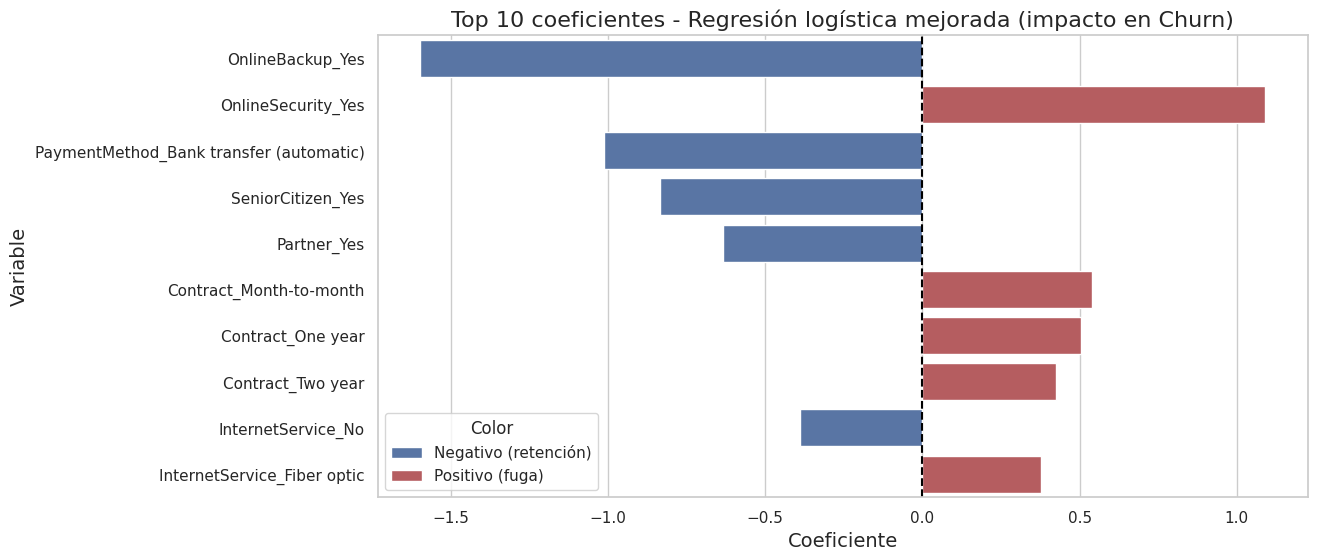

Se evidencia que este modelo asocia fuertemente la retención a clientes con el servicio de backup online. También le da un alto peso a la retención a factores como al pago automático con transferencia bancaria, a los clientes con más de 60 años y aquellos tienen pareja.

Por otro lado, y de manera llamativa, el modelo identifica una correlación positiva fuerte entre la fuga y el servicio de seguridad online, lo que sugiere que este segmento de clientes podría estar experimentando fricciones técnicas o que dicha variable captura el comportamiento de un segmento de clientes propensos a migrar si la oferta no es competitiva. Luego, se tiene el tipo de contrato y el internet de fibra óptica como variables que se asocian a la fuga de clientes.

Random forest mejorado.

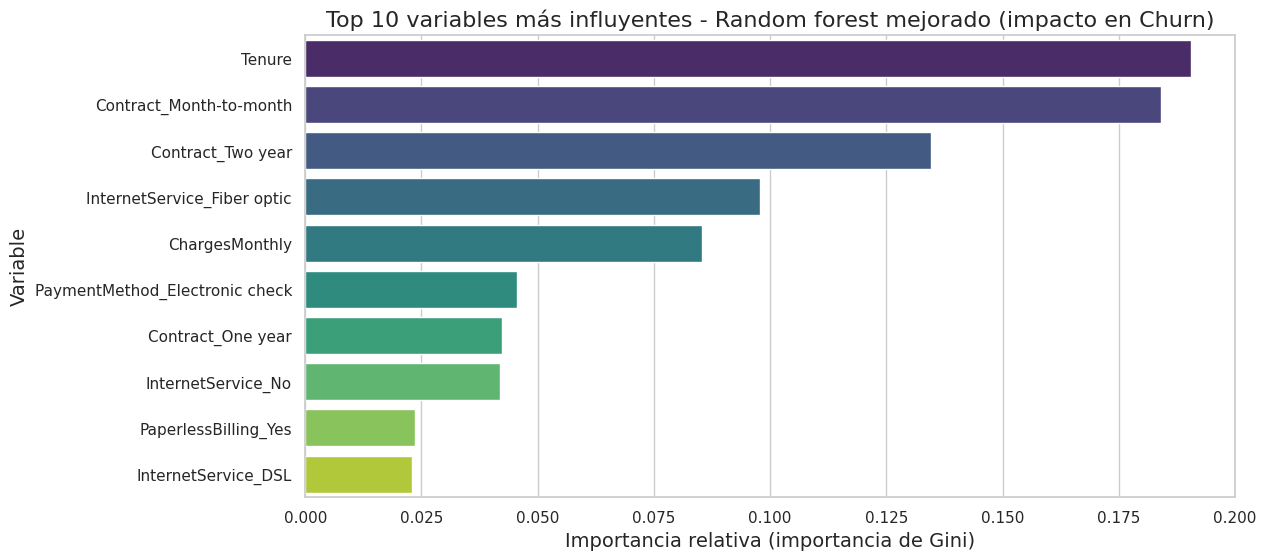

En este caso, el modelo considera como variables más relevantes la antigüedad del cliente (`Tenure`), los tipos de contrato mensual y a dos años, los que cuentan con internet de fibra óptica y el cargo mensual.

### Elección del modelo de mejor desempeño

De acuerdo con el análisis realizado, se selecciona la regresión logística mejorada como el modelo predictivo principal debido a su equilibrio óptimo entre precisión y operatividad. A diferencia de modelos más complejos como el random forest, que actúan como cajas negras, este algoritmo ofrece una transparencia total en la toma de decisiones.

Su arquitectura permite una implementación más ágil para la empresa, garantizando una estabilidad superior ante nuevos datos de clientes. Además, su simplicidad computacional asegura que el procesamiento de grandes volúmenes de información sea eficiente y de bajo costo de mantenimiento.

### Validación del modelo con nuevos datos

Para validar que el modelo escogido interactúa de forma lógica en escenarios reales, se sometió a una prueba con nuevos datos simulados con perfiles opuestos cuantificar el grado de certeza en su predicción respecto a la fuga de cada perfil:

* Perfil A: Cliente fidelizado.
* Perfil B: Cliente en riesgo de fuga.

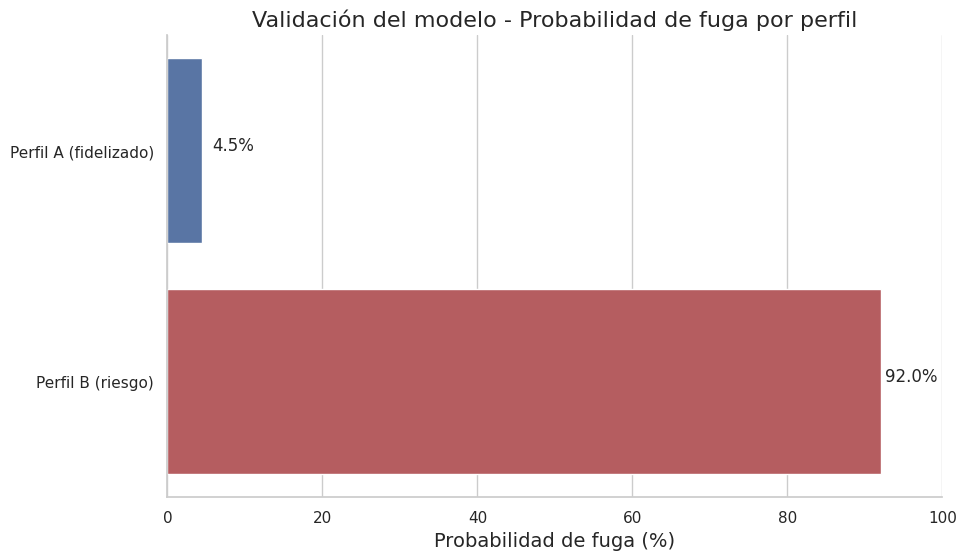

La regresión logística mejorada es capaz de predecir de manera clara que el perfil A representa un cliente que se mantendría en la empresa (probabilidad de fuga del 4.5%), y que el perfil B representa un cliente en riesgo de fuga (probabilidad de fuga del 92.0%), lo que concuerda con lo que se esperaría para cada perfil.

Esto da cuenta de la robustez y capacidad de discriminación del modelo. La contundencia de estos porcentajes permite a la empresa identificar clientes en riesgo de fuga, y además priorizar estrategias de retención de acuerdo con la probabilidad de dicho riesgo, optimizando recursos.

## Conclusiones y recomendaciones

### Factores críticos de retención y fuga

El estudio revela que la estabilidad del cliente no depende de un solo factor, sino de una combinación de servicios y compromiso contractual.

* La fidelidad es clave: El servicio de backup online y los métodos de pago automáticos actúan como anclas de retención. Fomentar la adopción de estos servicios en clientes nuevos reduciría drásticamente el riesgo inicial.

* El punto de fricción: El internet de fibra óptica asociada a contratos mensuales es una combinación peligrosa. Urge revisar la calidad del servicio técnico asociado al internet de este tipo y la competitividad de precios en este segmento específico, ya que presenta tasas de fuga altas.

### Efectividad del modelo implementado

La elección de la regresión logística mejorada como mejor modelo predictor ha demostrado ser acertada no solo por sus excelentes métricas de rendimiento, sino que también por su capacidad de ofrecer una puntuación de riesgo clara y procesable (la probabilidad de fuga).

* La validación con perfiles extremos confirmó su excelente capacidad de discriminación, logrando diferenciar claramente un perfil seguro de uno crítico.

* Al ser un modelo interpretable, permite explicar a la empresa exactamente qué variables están afectando a cada cliente, tanto en dirección como en grado, eliminando la incertidumbre de otros modelos más complejos.

### Recomendaciones estratégicas

Finalmente, se recomienda a Telecom X algunas acciones estratégicas a tener en cuenta con el fin de mitigar el riesgo de fuga:

* Campañas de migración contractual: Incentivar el paso de contratos mensuales a contratos por uno o dos años, especialmente en usuarios de fibra óptica, mediante beneficios como descuentos o servicios de valor agregado.

* Sistema de alerta temprana: Implementar el modelo para revisar la base de clientes periódicamente. Clientes con una probabilidad de fuga superior al umbral de decisión establecido (por ejemplo: 70%) deberían ser derivados a un equipo de retención proactiva antes de que finalice su ciclo de facturación, y así disminuir el riesgo de fuga.

* Fidelización del segmento senior: Aprovechar la baja tasa de fuga de los adultos mayores para ofrecer paquetes familiares que favorezcan la captación de otros miembros del hogar hacia la empresa.